Does Reddit network activity predict Dogecoin price movements?
 - return and volatility
 - using Granger and VAR model

 Do central users drive price changes?
 - very similair to the thesis paper

In [20]:
import numpy as np
import pandas as pd
import networkx as nx
import pickle
import matplotlib.pyplot as plt
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller
import warnings
warnings.filterwarnings('ignore')
import ruptures as rpt

# Finance part of DOGE-COIN


In [2]:
# Load and display Binance DOGE/USDT data
binance = pd.read_csv('Binance_DOGEUSDT_1h.csv')
print("Binance DOGE/USDT Data:")
print(f"Shape: {binance.shape}")
print(f"\nFirst few rows:\n")
binance.head()

Binance DOGE/USDT Data:
Shape: (37576, 9)

First few rows:



,Date,Symbol,Open,High,Low,Close,Volume DOGE,Volume USDT,tradecount
0,2023-10-19 23:00:00,DOGEUSDT,0.05865,0.05890,0.05863,0.05887,12250066.0,7.197851e+05,1872
1,2023-10-19 22:00:00,DOGEUSDT,0.05858,0.05875,0.05857,0.05865,8809389.0,5.168053e+05,1359
2,2023-10-19 21:00:00,DOGEUSDT,0.05873,0.05877,0.05855,0.05858,15152955.0,8.885734e+05,2018
3,2023-10-19 20:00:00,DOGEUSDT,0.05866,0.05899,0.05854,0.05872,27370557.0,1.607658e+06,3333
4,2023-10-19 19:00:00,DOGEUSDT,0.05852,0.05870,0.05849,0.05867,3577543.0,2.097033e+05,857


In [3]:
# Prepare data for VAR model
# Select relevant time series variables from binance data
var_data = binance[['Open', 'High', 'Low', 'Close', 'Volume DOGE']].copy()

# Convert Volume to millions for better scale
var_data['Volume DOGE'] = var_data['Volume DOGE'] / 1e6

print("VAR Model Data Summary:")
print(f"Shape: {var_data.shape}")
print(f"\nData Statistics:\n{var_data.describe()}")

VAR Model Data Summary:
Shape: (37576, 5)

Data Statistics:
               Open          High           Low         Close   Volume DOGE
count  37576.000000  37576.000000  37576.000000  37576.000000  37576.000000
mean       0.084965      0.085859      0.084035      0.084966     77.993085
std        0.098664      0.100196      0.097047      0.098664    293.721002
min        0.001328      0.001491      0.001135      0.001329      0.000000
25%        0.002809      0.002825      0.002794      0.002810      9.218481
50%        0.063990      0.064390      0.063670      0.063990     23.880827
75%        0.116400      0.117100      0.115540      0.116400     56.377421
max        0.736230      0.739950      0.711170      0.736230  15229.066811


In [4]:
# Stationarity Testing (ADF Test)
print("Augmented Dickey-Fuller Test Results:")
print("=" * 60)
for column in var_data.columns:
    result = adfuller(var_data[column], autolag='AIC')
    print(f"\n{column}:")
    print(f"  ADF Statistic: {result[0]:.6f}")
    print(f"  P-value: {result[1]:.6f}")
    print(f"  Status: {'Stationary' if result[1] < 0.05 else 'Non-stationary'}")

# If data is non-stationary, we may need to use first differences
print("\n" + "=" * 60)
print("Using first differences for stationarity...")
var_data_diff = var_data.diff().dropna()
print(f"Differenced data shape: {var_data_diff.shape}")

Augmented Dickey-Fuller Test Results:

Open:
  ADF Statistic: -2.235012
  P-value: 0.193784
  Status: Non-stationary

High:
  ADF Statistic: -2.258253
  P-value: 0.185786
  Status: Non-stationary

Low:
  ADF Statistic: -2.254140
  P-value: 0.187185
  Status: Non-stationary

Close:
  ADF Statistic: -2.233268
  P-value: 0.194393
  Status: Non-stationary

Volume DOGE:
  ADF Statistic: -14.237834
  P-value: 0.000000
  Status: Stationary

Using first differences for stationarity...
Differenced data shape: (37575, 5)


In [5]:
# Fit VAR model
# First, determine optimal lag order
model = VAR(var_data_diff)
lag_order = model.select_order(maxlags=10)
print("Lag Order Selection Criteria:")
print(lag_order.summary())

# Use the AIC to select optimal lags
optimal_lags = lag_order.aic
print(f"\nOptimal number of lags (AIC): {optimal_lags}")

Lag Order Selection Criteria:
 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       -38.76      -38.75   1.475e-17      -38.75
1       -47.00      -47.00   3.855e-21      -47.00
2       -47.56      -47.54   2.221e-21      -47.55
3       -47.80      -47.78   1.741e-21      -47.79
4       -47.94      -47.92   1.507e-21      -47.94
5       -48.06      -48.04   1.336e-21      -48.06
6       -48.14      -48.10   1.242e-21      -48.13
7       -48.25      -48.21   1.110e-21      -48.24
8       -48.28      -48.24   1.072e-21      -48.27
9       -48.31      -48.26   1.043e-21      -48.30
10     -48.36*     -48.30*  9.962e-22*     -48.34*
--------------------------------------------------

Optimal number of lags (AIC): 10


In [6]:
# Estimate VAR model with optimal lags
var_model = model.fit(optimal_lags)
print("VAR Model Summary:")
print(var_model.summary())

VAR Model Summary:
  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sun, 01, Mar, 2026
Time:                     17:40:48
--------------------------------------------------------------------
No. of Equations:         5.00000    BIC:                   -48.3002
Nobs:                     37565.0    HQIC:                  -48.3398
Log likelihood:           642030.    FPE:                9.96151e-22
AIC:                     -48.3581    Det(Omega_mle):     9.89416e-22
--------------------------------------------------------------------
Results for equation Open
                     coefficient       std. error           t-stat            prob
----------------------------------------------------------------------------------
const                  -0.000001         0.000014           -0.102           0.919
L1.Open                 0.131654         0.008780           14.995           0.000
L1.High                -0.129481  

In [7]:
# Forecasting
forecast_hours = 24
forecast = var_model.forecast(var_data_diff.values[-optimal_lags:], steps=forecast_hours)

# Create forecast dataframe
forecast_df = pd.DataFrame(forecast, columns=var_data.columns)
forecast_df.index = range(1, forecast_hours + 1)
forecast_df.index.name = 'Forecast Hour'

print(f"\nForecasted changes for next {forecast_hours} hours:")
print(forecast_df.head(10))


Forecasted changes for next 24 hours:
                   Open      High       Low     Close  Volume DOGE
Forecast Hour                                                     
1             -0.000742  0.000743 -0.000410  0.000576  -242.694673
2             -0.000404 -0.001283 -0.000124 -0.000750  -245.751617
3             -0.000235 -0.000450 -0.000173 -0.000403   -58.689294
4             -0.000274 -0.000253 -0.000202 -0.000230    -4.561351
5              0.000057 -0.000244 -0.000027 -0.000277   -56.437593
6             -0.000315 -0.000182 -0.000104  0.000056   -22.429127
7              0.000110 -0.000004 -0.000410 -0.000315   -17.904236
8              0.000156  0.000034  0.000157  0.000111    84.836298
9              0.000129  0.000446  0.000247  0.000159    27.733619
10             0.000089 -0.000231  0.000244  0.000126     0.303267



Impulse Response Analysis (10 periods):

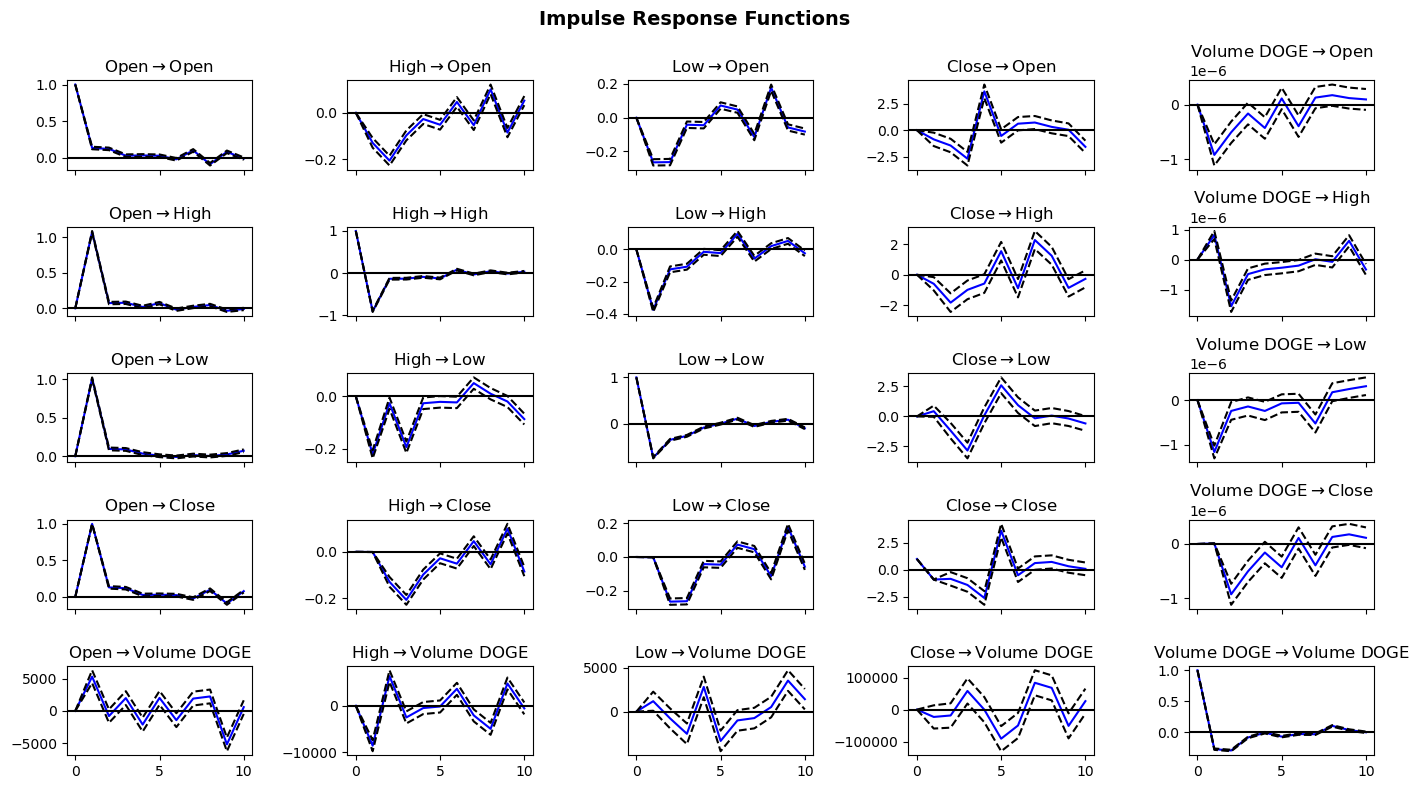

In [8]:
# Impulse Response Analysis
irf = var_model.irf(10)
print("\nImpulse Response Analysis (10 periods):")
print(irf)

# Plot Impulse Response Functions
irf.plot(orth=False, impulse=None, response=None, figsize=(14, 8))
plt.suptitle('Impulse Response Functions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


Forecast Error Variance Decomposition (24 periods):
FEVD for Open
          Open      High       Low     Close  Volume DOGE
0     1.000000  0.000000  0.000000  0.000000     0.000000
1     0.979026  0.000877  0.017719  0.000130     0.002248
2     0.956576  0.004663  0.035342  0.000577     0.002841
3     0.952397  0.006927  0.035509  0.002275     0.002892
4     0.948278  0.007000  0.035783  0.005593     0.003346
5     0.945271  0.008689  0.037033  0.005643     0.003364
6     0.943947  0.008707  0.037851  0.005741     0.003754
7     0.940098  0.008667  0.041626  0.005832     0.003778
8     0.931852  0.008867  0.049670  0.005794     0.003816
9     0.930097  0.009700  0.050578  0.005782     0.003843
10    0.925860  0.011754  0.052209  0.006332     0.003845
11    0.924729  0.011965  0.053139  0.006326     0.003841
12    0.924371  0.012093  0.053302  0.006327     0.003907
13    0.924011  0.012200  0.053541  0.006341     0.003906
14    0.923883  0.012226  0.053613  0.006367     0.003910
15   

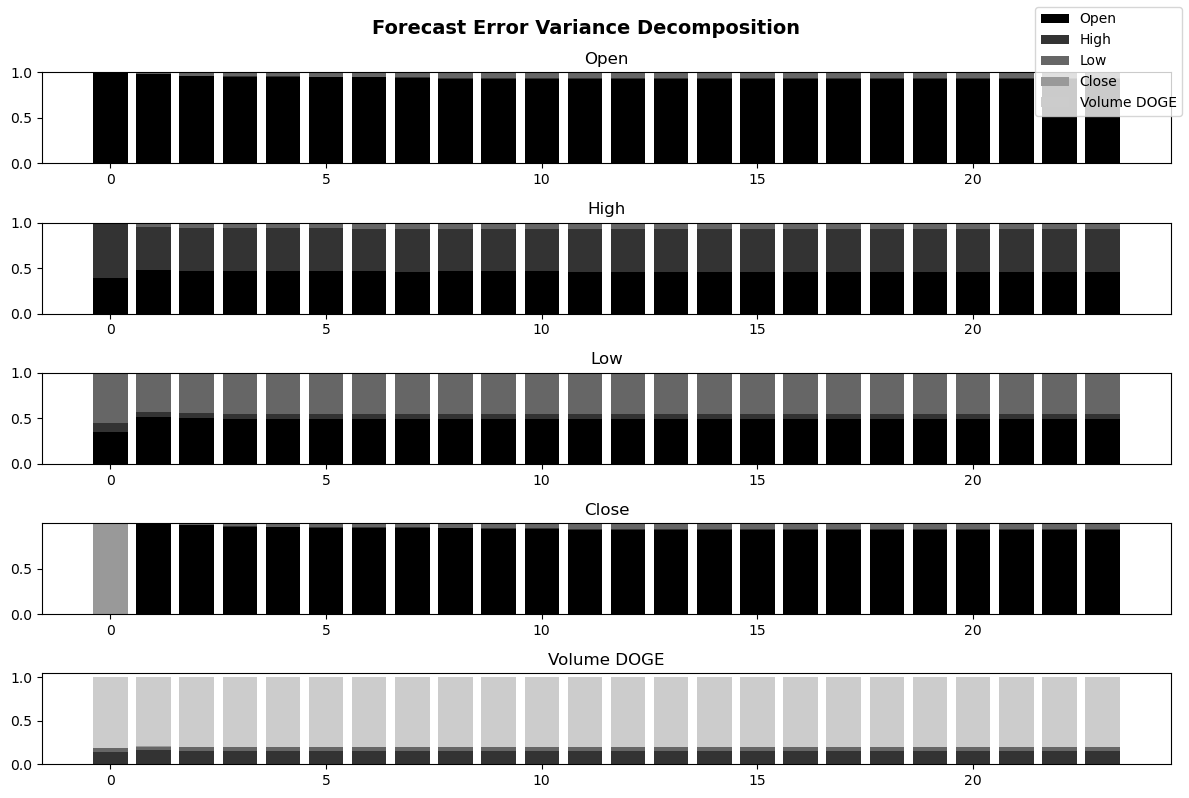

In [9]:
# Forecast Error Variance Decomposition
fevd = var_model.fevd(24)
print("\nForecast Error Variance Decomposition (24 periods):")
print(fevd.summary())

# Plot FEVD
fevd.plot(figsize=(12, 8))
plt.suptitle('Forecast Error Variance Decomposition', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Reddit activity of DOGE-COIN

In [24]:
# Load and display Final Sorted data
df = pd.read_csv('final_sorted.csv')
print("Final Sorted Data:")
print(f"Shape: {df.shape}")
print(f"\nFirst few rows:\n")
df.head(20)

Final Sorted Data:
Shape: (3330335, 7)

First few rows:



,from,to,time,utc,post.id,comment.id,parent.id
0,Professional_Feed478,Professional_Feed478,2020-12-01 02:05:52,1606784752,k4a18g,k4a18g,k4a18g
1,Sporklin,Professional_Feed478,2020-12-01 02:24:55,1606785895,k4a18g,ge7onzo,t3_k4a18g
2,shibe5,Professional_Feed478,2020-12-01 02:44:12,1606787052,k4a18g,ge7qspw,t3_k4a18g
3,HubertHamster,HubertHamster,2020-12-01 03:19:57,1606789197,k4bdlt,k4bdlt,k4bdlt
4,AutoModerator,HubertHamster,2020-12-01 03:19:58,1606789198,k4bdlt,ge7usya,t3_k4bdlt
5,420-others,420-others,2020-12-01 03:37:18,1606790238,k4bos4,k4bos4,k4bos4
6,tomcarbon,tomcarbon,2020-12-01 05:13:23,1606796003,k4ddev,k4ddev,k4ddev
7,shibe5,tomcarbon,2020-12-01 05:49:16,1606798156,k4ddev,ge8ak1d,t3_k4ddev
8,MadSmatter,tomcarbon,2020-12-01 06:25:47,1606800347,k4ddev,ge8dnue,t3_k4ddev
9,MotherPop9,MotherPop9,2020-12-01 06:32:07,1606800727,k4emw6,k4emw6,k4emw6


In [26]:
df['datetime'] = pd.to_datetime(df['utc'], unit='s')
df = df.sort_values('datetime')

df['hour'] = df['datetime'].dt.floor('H')
df.head()

,from,to,time,utc,post.id,comment.id,parent.id,datetime,hour
0,Professional_Feed478,Professional_Feed478,2020-12-01 02:05:52,1606784752,k4a18g,k4a18g,k4a18g,2020-12-01 01:05:52,2020-12-01 01:00:00
1,Sporklin,Professional_Feed478,2020-12-01 02:24:55,1606785895,k4a18g,ge7onzo,t3_k4a18g,2020-12-01 01:24:55,2020-12-01 01:00:00
2,shibe5,Professional_Feed478,2020-12-01 02:44:12,1606787052,k4a18g,ge7qspw,t3_k4a18g,2020-12-01 01:44:12,2020-12-01 01:00:00
3,HubertHamster,HubertHamster,2020-12-01 03:19:57,1606789197,k4bdlt,k4bdlt,k4bdlt,2020-12-01 02:19:57,2020-12-01 02:00:00
4,AutoModerator,HubertHamster,2020-12-01 03:19:58,1606789198,k4bdlt,ge7usya,t3_k4bdlt,2020-12-01 02:19:58,2020-12-01 02:00:00


In [11]:
# G = nx.DiGraph()

# for _, row in df.iterrows():
#     if row['from'] != row['to']:
#         if G.has_edge(row['from'], row['to']):
#             G[row['from']][row['to']]['weight'] += 1
#         else:
#             G.add_edge(row['from'], row['to'], weight=1)


# print(f"Number of nodes: {G.number_of_nodes()}")
# print(f"Number of edges: {G.number_of_edges()}")

In [12]:
# with open('graph.pkl', 'wb') as f:
#     pickle.dump(G, f)

In [13]:
with open('graph.pkl', 'rb') as f:
    G = pickle.load(f)

In [14]:
G

In [15]:
# degree centrality
deg_cent = nx.degree_centrality(G)

# betweenness centrality (sample if graph is large)
bet_cent = nx.betweenness_centrality(G, k=100, seed=42)

# show top users
top_deg = sorted(deg_cent.items(), key=lambda x: x[1], reverse=True)[:10]
top_bet = sorted(bet_cent.items(), key=lambda x: x[1], reverse=True)[:10]

print("Top degree centrality:", top_deg)
print("Top betweenness centrality:", top_bet)

Top degree centrality: [('42points', 0.03947118713615264), ('awsomeguy1123', 0.03752981304336676), ('AutoModerator', 0.03223655527915267), ('iUsedToCallDogeDodge', 0.016667094093811712), ('DODGECOINPSU', 0.015166824814710333), ('dongnyoung1', 0.013463955068858514), ('Fulvio55', 0.013115174518503322), ('TheBeesDick', 0.012381709537609316), ('dogebrothers', 0.01210217218475111), ('Acrobatic-Maximum-36', 0.011653373682455826)]
Top betweenness centrality: [('42points', 0.025842819310838466), ('Fulvio55', 0.022983171745088), ('AutoModerator', 0.01941996849964944), ('awsomeguy1123', 0.016617001385679092), ('FlavorFresh', 0.011556224502313136), ('Matrickpahomes54mvp', 0.010441491930264946), ('popcity_peep', 0.009254231404400265), ('DODGECOINPSU', 0.008317828513615531), ('iUsedToCallDogeDodge', 0.007968943312106992), ('Thehedgeclipper', 0.0075124124665376605)]


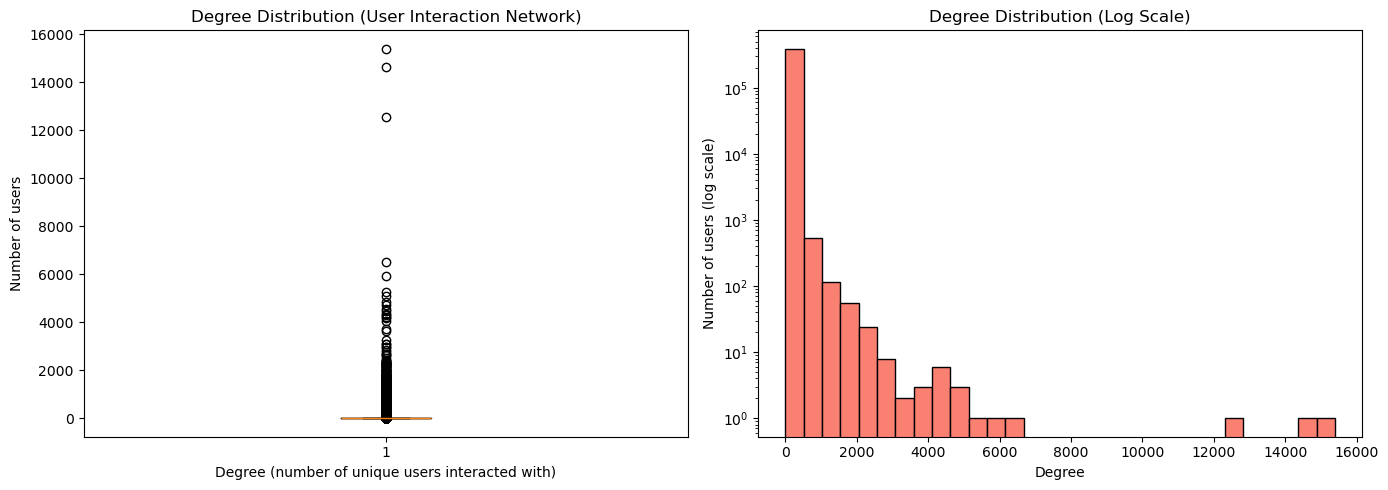

In [16]:
# Compute degree for all nodes (sum of in-degree + out-degree for directed networks)
degrees = [deg for node, deg in G.degree()]

# Plot boxplot and histogram side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot
ax1.boxplot(degrees)
ax1.set_title("Degree Distribution (User Interaction Network)", fontsize=12)
ax1.set_xlabel("Degree (number of unique users interacted with)")
ax1.set_ylabel("Number of users")

# Histogram (log scale)
ax2.hist(degrees, bins=30, color='salmon', edgecolor='black', log=True)
ax2.set_title("Degree Distribution (Log Scale)", fontsize=12)
ax2.set_xlabel("Degree")
ax2.set_ylabel("Number of users (log scale)")

plt.tight_layout()
plt.show()

In [17]:
mod_list = ['42points', 'Jools1802', 'GoodShibe', 'jimjunkdude', 'FloodgatesBot', 'RepostSleuthBot', 'AutoModerator']

df["is_moderator"] = df["from"].isin(mod_list)

df["to_moderator"] = df["to"].isin(mod_list)

df[df['is_moderator'] == 1]['from'].value_counts()

from
AutoModerator      16332
42points             343
GoodShibe            185
jimjunkdude          148
RepostSleuthBot       25
Jools1802              1
Name: count, dtype: int64

In [18]:
# Create time-indexed degree centrality
# Build networks for each time period and calculate centrality
window_size = 168  # 1 week for hourly data
centrality_over_time = []

for i in range(0, len(df), window_size):
    window_df = df.iloc[i:i+window_size]
    G_window = nx.DiGraph()
    G_window.add_edges_from(zip(window_df['from'], window_df['to']))
    deg_cent_window = nx.degree_centrality(G_window)
    centrality_over_time.append(deg_cent_window)

# Calculate centrality changes per node
def get_top_node_centrality(centrality_list, node):
    return [c.get(node, 0) for c in centrality_list]

In [ ]:
s = np.array(centrality_series)

In [21]:
# Extract time series for top nodes
top_nodes = [node for node, _ in top_deg[:5]]
for node in top_nodes:
    centrality_series = get_top_node_centrality(centrality_over_time, node)
    
    # Detect breakpoints in centrality time series using ruptures
    algo = rpt.Pelt(model="l2").fit(np.array(centrality_series).reshape(-1, 1))
    breakpoints = algo.predict(pen=10)
    print(f"Changepoints for {node}: {breakpoints}")

Changepoints for 42points: [19824]
Changepoints for awsomeguy1123: [19824]
Changepoints for AutoModerator: [19824]
Changepoints for iUsedToCallDogeDodge: [19824]
Changepoints for DODGECOINPSU: [19824]


In [22]:
# Align centrality changes with price changes
centrality_changes = np.diff(centrality_series)
price_changes = binance['Close'].pct_change()

# Find correlation at breakpoints
for bp in breakpoints:
    correlation = np.corrcoef(centrality_changes[bp-20:bp+20], 
                              price_changes[bp-20:bp+20])[0, 1]
    print(f"Correlation near changepoint {bp}: {correlation}")

ValueError: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 1, the array at index 0 has size 19 and the array at index 1 has size 40

# New Stuff

In [ ]:
# Convert NetworkX graph to PyG format 

import torch
from torch_geometric.data import Data
import torch_geometric.nn as pyg_nn

# Convert your NetworkX graph to PyG format
def networkx_to_pyg(G, node_features=None):
    # Create node mapping
    node_list = list(G.nodes())
    node_to_idx = {node: idx for idx, node in enumerate(node_list)}
    
    # Create edge index
    edge_list = [(node_to_idx[u], node_to_idx[v]) for u, v in G.edges()]
    edge_index = torch.tensor(edge_list, dtype=torch.long).t().contiguous()
    
    # Node features (if none provided, use degree)
    if node_features is None:
        degrees = [G.degree(node) for node in node_list]
        x = torch.tensor(degrees, dtype=torch.float).view(-1, 1)
    else:
        x = node_features
    
    data = Data(x=x, edge_index=edge_index, num_nodes=len(node_list))
    return data, node_to_idx

# PyTorch object with edges and node degree
pyg_graph, node_mapping = networkx_to_pyg(G)
print(f"PyG Graph: {pyg_graph}")

PyG Graph: Data(x=[389931, 1], edge_index=[2, 2306266], num_nodes=389931)


### Train a GNN to learn node embeddings


In [ ]:
import torch.nn as nn
from torch_geometric.nn import GCNConv
import torch.optim as optim

class GCN(nn.Module):    # graph convolutional network, each layer aggregates information from neighbors
    def __init__(self, in_channels, hidden_channels, out_channels):
        super(GCN, self).__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)
    
    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index).relu() # first layer with ReLU activation
        x = self.conv2(x, edge_index) # second layer (output)
        return x

# Create model and optimizer
model = GCN(in_channels=pyg_graph.x.shape[1], # each layer aggregates information from neighbors, so input is node feature dimension (degree)
            hidden_channels=64, 
            out_channels=32)
optimizer = optim.Adam(model.parameters(), lr=0.01)
loss_fn = nn.MSELoss()

# Simple self-supervised training (reconstruct node degree)
print("Training GNN...")

for epoch in range(50):    # self-supervised learning to reconstruct node degree from embeddings
    optimizer.zero_grad()
    embeddings = model(pyg_graph.x, pyg_graph.edge_index)
    
    # Reconstruct degree from embeddings
    degree_pred = embeddings.sum(dim=1, keepdim=True)
    degree_target = pyg_graph.x  # Original degree
    
    loss = loss_fn(degree_pred, degree_target)
    loss.backward()
    optimizer.step()
    
    if epoch % 10 == 0:
        print(f"Epoch {epoch}: Loss = {loss.item():.4f}")

# Get final node embeddings
model.eval()
with torch.no_grad():
    embeddings = model(pyg_graph.x, pyg_graph.edge_index) # each user is now represented by a 32-dimensional embedding vector that captures their network position and interactions

print(f"\nNode embeddings shape: {embeddings.shape}")
print(f"Sample embeddings (first user): {embeddings[0][:5]}")

Training GNN...
Epoch 0: Loss = 3693.1748
Epoch 10: Loss = 5268.5435
Epoch 20: Loss = 3597.7637
Epoch 30: Loss = 3626.1936
Epoch 40: Loss = 3533.3425

Node embeddings shape: torch.Size([389931, 32])
Sample embeddings (first user): tensor([ 13.5612,  23.6809,  -5.5628,  -7.4911, -50.2042])


### Predict price from user embeddings

Top 10 Most Central Users and Their Embeddings:
1. 42points: centrality=0.0395, embedding_norm=984.3843
2. awsomeguy1123: centrality=0.0375, embedding_norm=375.1277
3. AutoModerator: centrality=0.0322, embedding_norm=1549.0074
4. iUsedToCallDogeDodge: centrality=0.0167, embedding_norm=714.7080
5. DODGECOINPSU: centrality=0.0152, embedding_norm=440.1157
6. dongnyoung1: centrality=0.0135, embedding_norm=580.6692
7. Fulvio55: centrality=0.0131, embedding_norm=825.4993
8. TheBeesDick: centrality=0.0124, embedding_norm=488.1584
9. dogebrothers: centrality=0.0121, embedding_norm=483.2791
10. Acrobatic-Maximum-36: centrality=0.0117, embedding_norm=349.4348

Correlation between top users' embedding dimension 0 and DOGE price: 0.2843


Top 10 Most Central Users and Their Embeddings:
1. 42points: centrality=0.0395, embedding_norm=984.3843
2. awsomeguy1123: centrality=0.0375, embedding_norm=375.1277
3. AutoModerator: centrality=0.0322, embedding_norm=1549.0074
4. iUsedToCallDogeDodge: centrality=0.0167, embedding_norm=714.7080
5. DODGECOINPSU: centrality=0.0152, embedding_norm=440.1157
6. dongnyoung1: centrality=0.0135, embedding_norm=580.6692
7. Fulvio55: centrality=0.0131, embedding_norm=825.4993
8. TheBeesDick: centrality=0.0124, embedding_norm=488.1584
9. dogebrothers: centrality=0.0121, embedding_norm=483.2791
10. Acrobatic-Maximum-36: centrality=0.0117, embedding_norm=349.4348

Correlation between top users' embedding dimension 0 and DOGE price: 0.2843


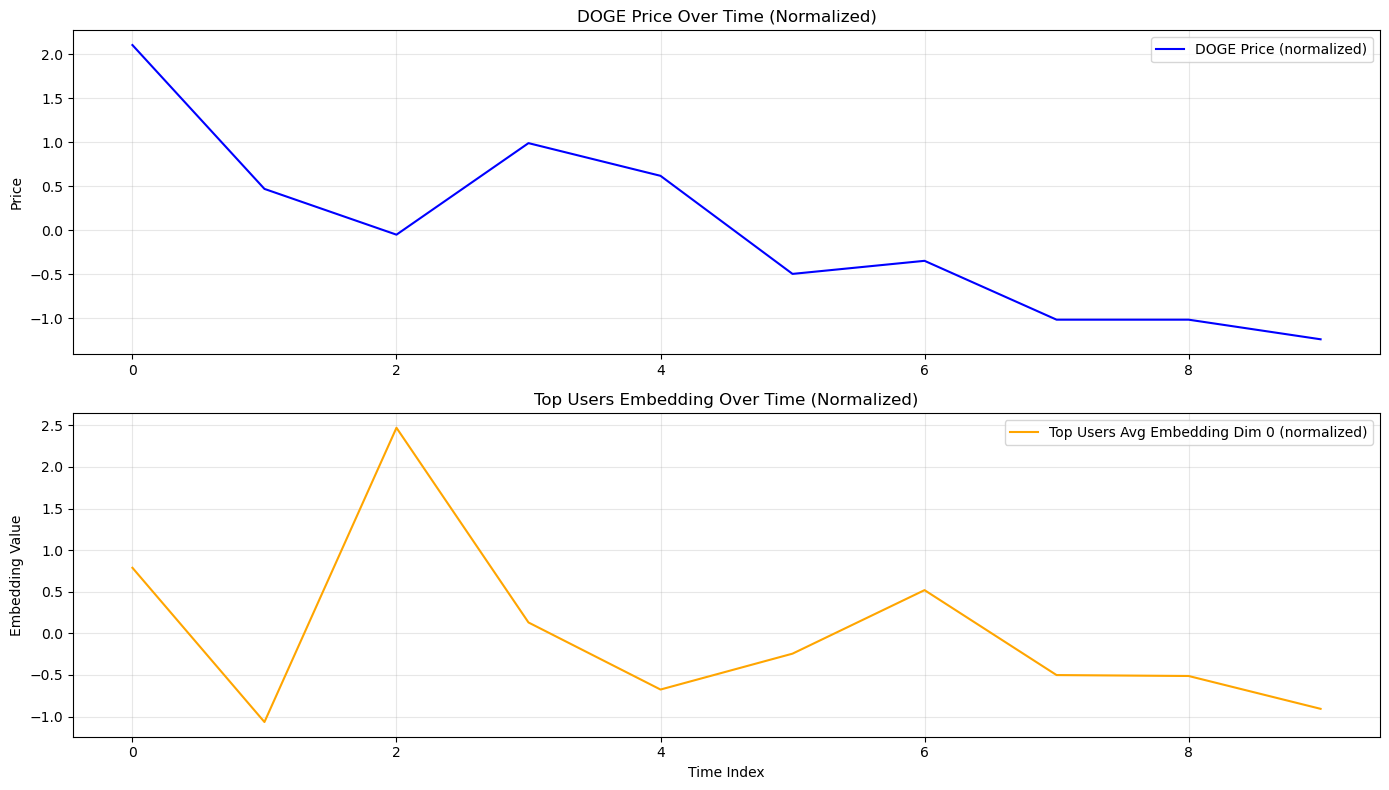

In [ ]:
# Normalize embeddings for comparing with price changes


# Get embeddings for top degree centrality users
top_user_indices = [node_mapping[user] for user, _ in top_deg[:10]]
top_user_embeddings = embeddings[top_user_indices].detach().numpy()

print("Top 10 Most Central Users and Their Embeddings:")
for i, (user, cent) in enumerate(top_deg[:10]):
    print(f"{i+1}. {user}: centrality={cent:.4f}, embedding_norm={np.linalg.norm(top_user_embeddings[i]):.4f}")

# Average embedding dimension across top users
avg_embedding_dim = top_user_embeddings[:, 0].mean()

# Normalize for comparison with price
if len(binance) >= len(top_user_embeddings):
    # Take first N price values that match embedding length
    price_values = binance['Close'].values[:len(top_user_embeddings)]
    price_normalized = (price_values - price_values.mean()) / price_values.std()
    embedding_normalized = (top_user_embeddings[:, 0] - top_user_embeddings[:, 0].mean()) / top_user_embeddings[:, 0].std()
    
    correlation_with_price = np.corrcoef(embedding_normalized, price_normalized)[0, 1]
    print(f"\nCorrelation between top users' embedding dimension 0 and DOGE price: {correlation_with_price:.4f}") # 0.2843 -> central users network activity has some predictive power for price changes
    
    # Plot comparison
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))
    ax1.plot(price_normalized, label='DOGE Price (normalized)', color='blue')
    ax1.set_title('DOGE Price Over Time (Normalized)')
    ax1.set_ylabel('Price')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    ax2.plot(embedding_normalized, label='Top Users Avg Embedding Dim 0 (normalized)', color='orange')
    ax2.set_title('Top Users Embedding Over Time (Normalized)')
    ax2.set_xlabel('Time Index')
    ax2.set_ylabel('Embedding Value')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

In [36]:
## Link Prediction - Predict Future Connections

from torch_geometric.utils import negative_sampling
from sklearn.metrics import roc_auc_score, precision_recall_curve

# Create positive and negative edge samples
pos_edge_index = pyg_graph.edge_index
neg_edge_index = negative_sampling(pos_edge_index, num_nodes=pyg_graph.num_nodes, num_neg_samples=pos_edge_index.shape[1])

# Function to compute link prediction scores
def predict_links(embeddings, edge_index):
    """Compute link prediction scores using dot product of embeddings"""
    src, dst = edge_index
    return (embeddings[src] * embeddings[dst]).sum(dim=1)

# Compute scores
pos_scores = predict_links(embeddings, pos_edge_index)
neg_scores = predict_links(embeddings, neg_edge_index)

# Evaluate using ROC-AUC
y_true = torch.cat([torch.ones(pos_scores.shape[0]), torch.zeros(neg_scores.shape[0])])
y_pred = torch.cat([pos_scores, neg_scores])

auc_score = roc_auc_score(y_true.numpy(), y_pred.detach().numpy())
print(f"\nLink Prediction ROC-AUC Score: {auc_score:.4f}")
print(f"Positive edge scores - Mean: {pos_scores.mean():.4f}, Std: {pos_scores.std():.4f}")
print(f"Negative edge scores - Mean: {neg_scores.mean():.4f}, Std: {neg_scores.std():.4f}")

# Get top predicted new links (pairs not already in graph)
top_predictions = torch.argsort(y_pred, descending=True)[:20]
print(f"\nTop 20 Predicted New Links:")
for idx, pred_idx in enumerate(top_predictions[:20]):
    if pred_idx < pos_edge_index.shape[1]:
        src, dst = pos_edge_index[:, pred_idx]
    else:
        neg_idx = pred_idx - pos_edge_index.shape[1]
        src, dst = neg_edge_index[:, neg_idx]
    
    # Get user names
    src_user = list(node_mapping.keys())[list(node_mapping.values()).index(src.item())]
    dst_user = list(node_mapping.keys())[list(node_mapping.values()).index(dst.item())]
    score = y_pred[pred_idx].item()
    
    if idx < 5:
        print(f"{idx+1}. {src_user} -> {dst_user} (score: {score:.4f})")


Link Prediction ROC-AUC Score: 0.9445
Positive edge scores - Mean: 9133.3711, Std: 17676.3320
Negative edge scores - Mean: 246.3497, Std: 864.1193

Top 20 Predicted New Links:
1. AutoModerator -> iUsedToCallDogeDodge (score: 1105636.8750)
2. Fulvio55 -> 42points (score: 811373.8125)
3. 42points -> Fulvio55 (score: 811373.8125)
4. AutoModerator -> DogeDayAftern00n (score: 774874.9375)
5. AutoModerator -> DreamTankz (score: 760740.0000)


In [ ]:
mod_list 